In [1]:
#facial expression recognition
import numpy as np 
import math 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import optimizers 
from tensorflow.keras.utils import to_categorical
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout,BatchNormalization, LeakyReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping , Callback

In [2]:
df = pd.read_csv('fer2013.csv')
df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [3]:
df.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1], dtype=int64)

In [4]:
emotion_label_to_text = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

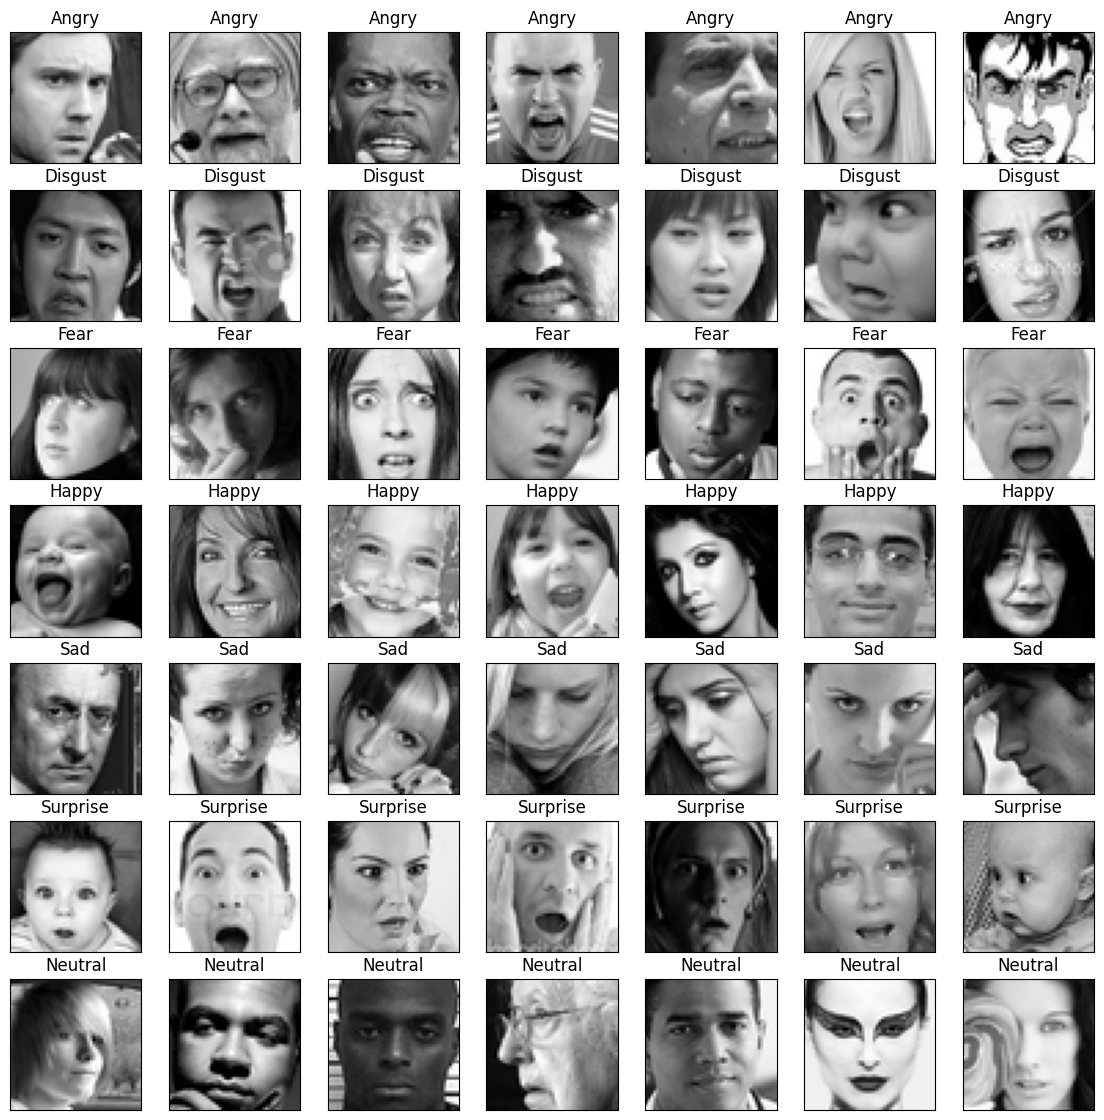

In [5]:
fig = plt.figure(1,(14,14))
k = 0 
for label in sorted(df.emotion.unique()):
    for j in range(7):
        px = df[df.emotion == label].pixels.iloc[k]
        px = np.array(px.split(" ")).reshape(48,48).astype('float32')
        k+=1
        ax = plt.subplot(7,7,k)
        ax.imshow(px,cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(emotion_label_to_text[label])

In [6]:
interested_label = [3,4,6]

In [7]:
df = df[df["emotion"].isin(interested_label)]
df.shape

(21264, 3)

In [8]:
##data compatible 
img_array = df.pixels.apply(lambda x :np.array(x.split(" ")).reshape(48,48).astype('float32'))
img_array = np.stack(img_array,axis=0)
img_array.shape

(21264, 48, 48)

In [9]:
le = LabelEncoder()
img_labels = le.fit_transform(df.emotion)
img_labels = to_categorical(img_labels)
img_labels.shape

(21264, 3)

In [10]:
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

In [11]:
le_name_mapping

{3: 0, 4: 1, 6: 2}

In [12]:
##train test split 
x_train,x_test,y_train,y_test = train_test_split(img_array
                                                 ,img_labels
                                                 ,test_size=0.1,
                                                 random_state=42,
                                                 shuffle=True,
                                                 stratify=img_labels)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((19137, 48, 48), (2127, 48, 48), (19137, 3), (2127, 3))

In [13]:
x_train = x_train.reshape(-1,48,48,1)
# -1 = keeep the no of sample unchanged and reshape it to 48,48,1
x_train.shape

(19137, 48, 48, 1)

In [14]:
img_width  = x_train.shape[1]
num_classes = y_train.shape[1]
img_height = x_train.shape[2]
img_depth  = x_train.shape[3]

In [15]:
##normalise data 
x_train = x_train/255
x_test = x_test/255

In [16]:
def build_net(optim):
    net = Sequential(name = "DCNN") 
    net.add(
        Conv2D(
            filters = 64,
            kernel_size = (5,5),
            input_shape = (img_width, img_height, img_depth),
            padding = "same",
            activation = "elu",
            kernel_initializer = "he_normal",
            name = "conv2d_1"
        )
    )
    ##bN is used after dense or before convo layer
    net.add(BatchNormalization(
        name = "batch_normalization_1"))
    net.add(
        Conv2D(
            filters = 64 ,
            kernel_size = (5,5),
            activation = "elu",
            padding = "same",
            kernel_initializer = "he_normal",
            name = "conv2d_2"
        )
    )
    net.add(BatchNormalization(
        name = "batch_normalization_2"))
    net.add(
        MaxPooling2D(
            pool_size = (2,2),
            name = "max_pooling2d_1"
        )
    )
    net.add(Dropout(0.4,name = "droput_1"))
    net.add(
        Conv2D(
            filters = 128 ,
            kernel_size = (3,3),
            activation = "elu",
            padding = "same",
            kernel_initializer = "he_normal",
            name = "conv2d_3"
        )
    )
    net.add(BatchNormalization(
        name = "batch_normalization_3"))
    net.add(
        Conv2D(
            filters = 128 ,
            kernel_size = (3,3),
            activation = "elu",
            padding = "same",
            kernel_initializer = "he_normal",
            name = "conv2d_4"
        )
    )
    net.add(BatchNormalization(
        name = "batch_normalization_4"))
    net.add(
        MaxPooling2D(
            pool_size = (2,2),
            name = "max_pooling2d_2"
        )
    )
    net.add(Dropout(0.4,name = "droput_2"))

    net.add(
        Conv2D(
            filters = 256 ,
            kernel_size = (3,3),
            activation = "elu",
            padding = "same",
            kernel_initializer = "he_normal",
            name = "conv2d_5"
        )
    )
    net.add(BatchNormalization(
        name = "batch_normalization_5"))
    net.add(
        Conv2D(
            filters = 256 ,
            kernel_size = (3,3),
            activation = "elu",
            padding = "same",
            kernel_initializer = "he_normal",
            name = "conv2d_6"
        )
    )
    net.add(BatchNormalization(
        name = "batch_normalization_6"))
    net.add(
        MaxPooling2D(
            pool_size = (2,2),
            name = "max_pooling2d_3"
        )
    )
    net.add(Dropout(0.5,name = "droput_3"))

    net.add(Flatten(name = "flatten"))
    net.add(
        Dense(
            128,
            activation = "elu",
            kernel_initializer = "he_normal",
            name = "dense_1"
        )
    )
    net.add(BatchNormalization(
        name = "batch_normalization_7"))
    net.add(Dropout(0.6,name = "droput_4"))
    net.add(
        Dense(num_classes,
            activation = "softmax",
            name = "out_layer"
        )
    )

    net.compile(
        loss = "categorical_crossentropy",
        optimizer = optim,
        metrics = ["accuracy"]
    )
    net.summary()
    return net

In [17]:
#callbacks -- special function that runs during training process at 
## different stages
## and there work is to control the training process 

##early stopping -- acc , loss , 

## reduce learning rate on plateau -- when validation loss 
## doesn't improve then you reduce your lr 



##learning rate -- hyperparameter that controls how much a
#  model weights  are updated during the training process



In [18]:
early_stopping = EarlyStopping(
    monitor = "val_accuracy",
    min_delta = 0.00005,
    ##change in acc to count as improvement 
    patience = 11 ,
    ##if acc doesn't improve for 11 epochs then stop training,
    verbose = 1,
    ## 0 = silent , 1 = progress bar , 2 = one line per epoch
    ## 2 = one line per epoch and summary,
    restore_best_weights = True,
    ##restore the best weights

)

reduce_lr = ReduceLROnPlateau(
    monitor = "val_accuracy",
    factor = 0.5,
    ##reduce lr by 50 %
    patience = 7,
    verbose = 1,
    min_lr = 1e-7

)
callbacks = [early_stopping,reduce_lr]

In [19]:
##random transformations apply to increase teh data set 
train_data_gen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.15,
    height_shift_range = 0.15,
    shear_range = 0.15,
    zoom_range = 0.15,
    horizontal_flip = True,
    
)
train_data_gen.fit(x_train)

In [20]:
batch_size = 64
epochs = 100
optim = [
    optimizers.Nadam(
        learning_rate = 0.001,
        beta_1 = 0.9,
        beta_2 = 0.999,
        epsilon = 1e-7,
        name = "Nadam"
    ),
    optimizers.Adam(learning_rate = 0.001)
]

In [ ]:
model = build_net(optim[1])
history = model.fit(
    train_data_gen.flow(
        x_train,
        y_train,
        batch_size = batch_size
    ),
    epochs = epochs , 
    validation_data = (x_test,y_test),
    callbacks = callbacks
)

In [ ]:
##model save adn load 
model_yaml = model.to_yaml()
with open("model.yaml","w") as yaml_file:
    yaml_file.write(model_yaml)
model.save_weights("model.h5")